# CURTAILMENT ANALYSE
## Met Totaal Verbruik

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Laad data
df_2024 = pd.read_excel(r'C:\Users\Badra\Nieuwe map\Howest\Project duurzameplan\Data\energie_orac_2024.xlsx')
df_2025 = pd.read_excel(r'C:\Users\Badra\Nieuwe map\Howest\Project duurzameplan\Data\energie_orac_2025.xlsx')

df_2024['datetime'] = pd.to_datetime(df_2024['datetime'])
df_2025['datetime'] = pd.to_datetime(df_2025['datetime'])

# Bereken totaal verbruik
df_2024['totaalverbruik'] = df_2024['productie_kwh'] + df_2024['afname_kwh'] - df_2024['injectie_kwh']
df_2025['totaalverbruik'] = df_2025['productie_kwh'] + df_2025['afname_kwh'] - df_2025['injectie_kwh']

# Filter mei t/m oktober
zomer_2024 = df_2024[(df_2024['datetime'].dt.month >= 5) & (df_2024['datetime'].dt.month <= 10)].copy()
zomer_2025 = df_2025[(df_2025['datetime'].dt.month >= 5) & (df_2025['datetime'].dt.month <= 10)].copy()

print("="*130)
print("EERLIJKE CURTAILMENT VERGELIJKING - MEI T/M OKTOBER 2024 vs 2025")
print("Gecorrigeerd voor productie, weersomstandigheden en verbruik")
print("="*130)

EERLIJKE CURTAILMENT VERGELIJKING - MEI T/M OKTOBER 2024 vs 2025
Gecorrigeerd voor productie, weersomstandigheden en verbruik


## METHODE 1: INJECTIE RATIO (Injectie / Productie)


In [2]:
print("\n" + "="*130)
print("METHODE 1: INJECTIE RATIO (Fairste Maat!)")
print("="*130)

print("\nInjectie Ratio = Injectie / Productie")
print("Dit zegt: 'Van alle energie die je produceert, hoeveel procent injecteer je?'")
print("Dit CORRIGEERT automatisch voor minder productie!")

totaal_2024 = {
    'Productie': zomer_2024['productie_kwh'].sum(),
    'Injectie': zomer_2024['injectie_kwh'].sum(),
    'Afname': zomer_2024['afname_kwh'].sum(),
    'Verbruik': zomer_2024['totaalverbruik'].sum(),
    'Records': len(zomer_2024)
}

totaal_2025 = {
    'Productie': zomer_2025['productie_kwh'].sum(),
    'Injectie': zomer_2025['injectie_kwh'].sum(),
    'Afname': zomer_2025['afname_kwh'].sum(),
    'Verbruik': zomer_2025['totaalverbruik'].sum(),
    'Records': len(zomer_2025)
}

inj_ratio_2024 = totaal_2024['Injectie'] / totaal_2024['Productie']
inj_ratio_2025 = totaal_2025['Injectie'] / totaal_2025['Productie']

print(f"\n2024 (Mei-Oktober):")
print(f"  Productie:      {totaal_2024['Productie']:>15,.0f} kWh")
print(f"  Injectie:       {totaal_2024['Injectie']:>15,.0f} kWh")
print(f"  Afname:         {totaal_2024['Afname']:>15,.0f} kWh")
print(f"  Totaal Verbruik:{totaal_2024['Verbruik']:>15,.0f} kWh")
print(f"  Injectie Ratio: {inj_ratio_2024:>14.1%}")

print(f"\n2025 (Mei-Oktober):")
print(f"  Productie:      {totaal_2025['Productie']:>15,.0f} kWh")
print(f"  Injectie:       {totaal_2025['Injectie']:>15,.0f} kWh")
print(f"  Afname:         {totaal_2025['Afname']:>15,.0f} kWh")
print(f"  Totaal Verbruik:{totaal_2025['Verbruik']:>15,.0f} kWh")
print(f"  Injectie Ratio: {inj_ratio_2025:>14.1%}")

curtailment_pct = (inj_ratio_2024 - inj_ratio_2025) / inj_ratio_2024 * 100

print(f"\nVERSCHIL:")
print(f"  Ratio diff:     {inj_ratio_2024 - inj_ratio_2025:>14.1%}")
print(f"  Curtailment:    {curtailment_pct:>14.1f}%")
print(f"  Verbruik diff:  {((totaal_2025['Verbruik'] - totaal_2024['Verbruik'])/totaal_2024['Verbruik']*100):>13.1f}%")

if curtailment_pct > 5:
    print(f"\n✓ SIGNIFICANT CURTAILMENT AANGETOOND!")
    print(f"  Van elke kWh die je produceert, injecteer je {inj_ratio_2025*100:.1f}% in 2025")
    print(f"  Terwijl je in 2024 {inj_ratio_2024*100:.1f}% injecteerde")
    print(f"  → {curtailment_pct:.1f}% MINDER injectie ratio!")


METHODE 1: INJECTIE RATIO (Fairste Maat!)

Injectie Ratio = Injectie / Productie
Dit zegt: 'Van alle energie die je produceert, hoeveel procent injecteer je?'
Dit CORRIGEERT automatisch voor minder productie!

2024 (Mei-Oktober):
  Productie:              863,559 kWh
  Injectie:               400,197 kWh
  Afname:                 764,730 kWh
  Totaal Verbruik:      1,228,092 kWh
  Injectie Ratio:          46.3%

2025 (Mei-Oktober):
  Productie:              699,191 kWh
  Injectie:               197,074 kWh
  Afname:                 781,662 kWh
  Totaal Verbruik:      1,281,989 kWh
  Injectie Ratio:          28.2%

VERSCHIL:
  Ratio diff:              18.2%
  Curtailment:              39.2%
  Verbruik diff:            4.4%

✓ SIGNIFICANT CURTAILMENT AANGETOOND!
  Van elke kWh die je produceert, injecteer je 28.2% in 2025
  Terwijl je in 2024 46.3% injecteerde
  → 39.2% MINDER injectie ratio!


## METHODE 2: EXPECTED vs ACTUAL INJECTIE


In [3]:
print("\n" + "="*130)
print("METHODE 2: EXPECTED vs ACTUAL INJECTIE")
print("="*130)

print("\nVerwacht: 'Als 2025 dezelfde % zou injecteren als 2024'")
print("Werkelijk: 'Wat 2025 daadwerkelijk injecteerde'")

expected_injection_2025 = totaal_2025['Productie'] * inj_ratio_2024
actual_injection_2025 = totaal_2025['Injectie']
curtailed_energy = expected_injection_2025 - actual_injection_2025
pct_curtailed = curtailed_energy / expected_injection_2025 * 100

print(f"\nExpected Injectie 2025 (op basis 2024 ratio):")
print(f"  {totaal_2025['Productie']:,.0f} kWh × {inj_ratio_2024:.1%} = {expected_injection_2025:,.0f} kWh")

print(f"\nActual Injectie 2025:")
print(f"  {actual_injection_2025:,.0f} kWh")

print(f"\nVerschil (waarschijnlijk CURTAILED):")
print(f"  {expected_injection_2025:,.0f} - {actual_injection_2025:,.0f} = {curtailed_energy:,.0f} kWh")

if curtailed_energy > 0:
    print(f"\n✓ Ongeveer {curtailed_energy:,.0f} kWh werd waarschijnlijk AFGEZET")
    print(f"  Dit is {pct_curtailed:.1f}% van wat je zou hebben geinjecteerd")


METHODE 2: EXPECTED vs ACTUAL INJECTIE

Verwacht: 'Als 2025 dezelfde % zou injecteren als 2024'
Werkelijk: 'Wat 2025 daadwerkelijk injecteerde'

Expected Injectie 2025 (op basis 2024 ratio):
  699,191 kWh × 46.3% = 324,024 kWh

Actual Injectie 2025:
  197,074 kWh

Verschil (waarschijnlijk CURTAILED):
  324,024 - 197,074 = 126,950 kWh

✓ Ongeveer 126,950 kWh werd waarschijnlijk AFGEZET
  Dit is 39.2% van wat je zou hebben geinjecteerd


## METHODE 3: GELIJKE PRODUCTIEDAGEN VERGELIJKEN


In [4]:
print("\n" + "="*130)
print("METHODE 3: VERGELIJKING OP BASIS VAN GELIJKE PRODUCTIEDAGEN")
print("="*130)

# Aggregeer per dag
dag_2024 = zomer_2024.groupby(zomer_2024['datetime'].dt.date).agg({
    'productie_kwh': 'sum',
    'injectie_kwh': 'sum',
    'afname_kwh': 'sum',
    'totaalverbruik': 'sum'
}).reset_index()
dag_2024.columns = ['datum', 'productie', 'injectie', 'afname', 'verbruik']
dag_2024 = dag_2024.sort_values('productie')

dag_2025 = zomer_2025.groupby(zomer_2025['datetime'].dt.date).agg({
    'productie_kwh': 'sum',
    'injectie_kwh': 'sum',
    'afname_kwh': 'sum',
    'totaalverbruik': 'sum'
}).reset_index()
dag_2025.columns = ['datum', 'productie', 'injectie', 'afname', 'verbruik']
dag_2025 = dag_2025.sort_values('productie')

print(f"\nAantal dagen: 2024: {len(dag_2024)} | 2025: {len(dag_2025)}")

# Maak bins van productie levels
n_bins = 5
dag_2024['bin'] = pd.qcut(dag_2024['productie'], q=n_bins, labels=False, duplicates='drop')
dag_2025['bin'] = pd.qcut(dag_2025['productie'], q=n_bins, labels=False, duplicates='drop')

# Vergelijk per bin
bin_comparison = []
for bin_num in sorted(dag_2024['bin'].unique()):
    if pd.notna(bin_num):
        data_24 = dag_2024[dag_2024['bin'] == bin_num]
        data_25 = dag_2025[dag_2025['bin'] == bin_num]
        
        if len(data_24) > 0 and len(data_25) > 0:
            prod_24 = data_24['productie'].sum()
            prod_25 = data_25['productie'].sum()
            inj_24 = data_24['injectie'].sum()
            inj_25 = data_25['injectie'].sum()
            verb_24 = data_24['verbruik'].sum()
            verb_25 = data_25['verbruik'].sum()
            
            inj_pct_24 = (inj_24 / prod_24 * 100) if prod_24 > 0 else 0
            inj_pct_25 = (inj_25 / prod_25 * 100) if prod_25 > 0 else 0
            diff = inj_pct_24 - inj_pct_25
            
            bin_comparison.append({
                'bin': int(bin_num) + 1,
                'prod_2024_range': f"{data_24['productie'].min():.0f}-{data_24['productie'].max():.0f}",
                'prod_2025_range': f"{data_25['productie'].min():.0f}-{data_25['productie'].max():.0f}",
                'inj_pct_24': inj_pct_24,
                'inj_pct_25': inj_pct_25,
                'diff': diff,
                'verb_2024': verb_24,
                'verb_2025': verb_25,
                'verb_diff': ((verb_25 - verb_24)/verb_24*100) if verb_24 > 0 else 0,
                'days_24': len(data_24),
                'days_25': len(data_25)
            })

comp_df = pd.DataFrame(bin_comparison)

print(f"\nGELIJKE PRODUCTIEDAGEN VERGELIJKEN (Elimineert Weersomstandigheden):\n")
print(f"{'Bin':<5} {'2024 Prod':<20} {'2025 Prod':<20} {'Inj% 24':<12} {'Inj% 25':<12} {'Verb 24':<12} {'Verb 25':<12} {'Verb Diff':<10}")
print("-" * 120)

for _, row in comp_df.iterrows():
    print(f"{row['bin']:<5} {row['prod_2024_range']:<20} {row['prod_2025_range']:<20} {row['inj_pct_24']:>10.1f}% {row['inj_pct_25']:>10.1f}% {row['verb_2024']:>10.0f} {row['verb_2025']:>10.0f} {row['verb_diff']:>8.1f}%")

avg_diff = comp_df['diff'].mean()
avg_verb_diff = comp_df['verb_diff'].mean()
print(f"\n✓ GEMIDDELD VERSCHIL: {avg_diff:.1f}%")
print(f"  2024: {comp_df['inj_pct_24'].mean():.1f}% injectie")
print(f"  2025: {comp_df['inj_pct_25'].mean():.1f}% injectie")
print(f"  → {avg_diff:.1f}% MINDER INJECTIE (CURTAILMENT!)")
print(f"\n✓ VERBRUIK VERSCHIL: {avg_verb_diff:.1f}%")
print(f"  2024 avg verbruik per groep: {comp_df['verb_2024'].mean():.0f} kWh")
print(f"  2025 avg verbruik per groep: {comp_df['verb_2025'].mean():.0f} kWh")


METHODE 3: VERGELIJKING OP BASIS VAN GELIJKE PRODUCTIEDAGEN

Aantal dagen: 2024: 184 | 2025: 184

GELIJKE PRODUCTIEDAGEN VERGELIJKEN (Elimineert Weersomstandigheden):

Bin   2024 Prod            2025 Prod            Inj% 24      Inj% 25      Verb 24      Verb 25      Verb Diff 
------------------------------------------------------------------------------------------------------------------------
1     640-2349             496-1815                   17.2%       30.8%     265434     157342    -40.7%
2     2375-3958            1853-2840                  33.8%       36.0%     250248     197634    -21.0%
3     3960-5015            2863-4358                  43.3%       28.9%     238410     249231      4.5%
4     5033-6844            4414-5674                  60.3%       17.6%     185297     353984     91.0%
5     6917-14574           5707-8328                  48.3%       32.6%     288703     323798     12.2%

✓ GEMIDDELD VERSCHIL: 11.4%
  2024: 40.6% injectie
  2025: 29.2% injectie
  → 

## GRAFIEKEN



GRAFIEKEN


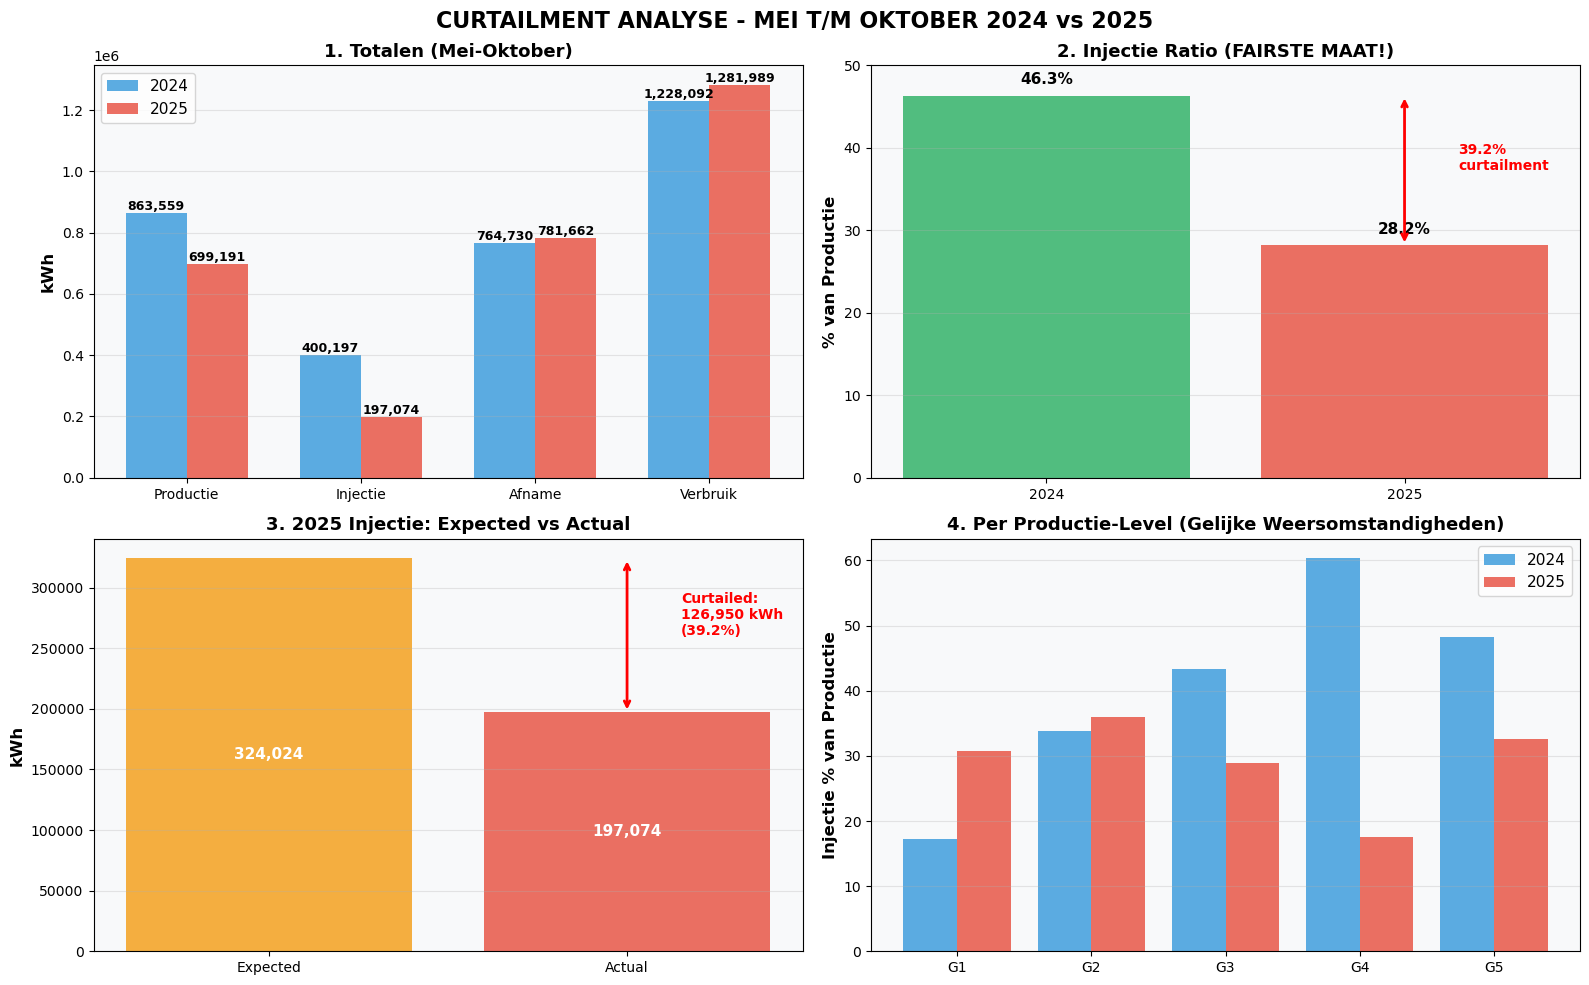

In [9]:
print("\n" + "="*130)
print("GRAFIEKEN")
print("="*130)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('CURTAILMENT ANALYSE - MEI T/M OKTOBER 2024 vs 2025', 
             fontsize=16, fontweight='bold')

# Grafiek 1: Totalen (met echte waardes)
ax1 = axes[0, 0]
metrics = ['Productie', 'Injectie', 'Afname', 'Verbruik']
vals_2024 = [totaal_2024['Productie'], totaal_2024['Injectie'], totaal_2024['Afname'], totaal_2024['Verbruik']]
vals_2025 = [totaal_2025['Productie'], totaal_2025['Injectie'], totaal_2025['Afname'], totaal_2025['Verbruik']]

x = np.arange(len(metrics))
width = 0.35

bars_2024 = ax1.bar(x - width/2, vals_2024, width, label='2024', alpha=0.8, color='#3498db')
bars_2025 = ax1.bar(x + width/2, vals_2025, width, label='2025', alpha=0.8, color='#e74c3c')

# Voeg echte waardes TOE op de bars
for bars in [bars_2024, bars_2025]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:,.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylabel('kWh', fontsize=12, fontweight='bold')
ax1.set_title('1. Totalen (Mei-Oktober)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_facecolor('#F8F9FA')

# Grafiek 2: Injectie Ratio (FAIRSTE MAAT!)
ax2 = axes[0, 1]
ratios = [inj_ratio_2024 * 100, inj_ratio_2025 * 100]
colors = ['#27AE60', '#E74C3C']
bars = ax2.bar(['2024', '2025'], ratios, alpha=0.8, color=colors)
ax2.set_ylabel('% van Productie', fontsize=12, fontweight='bold')
ax2.set_title('2. Injectie Ratio (FAIRSTE MAAT!)', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 50)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('#F8F9FA')

# Voeg waarden toe op bars
for i, (bar, val) in enumerate(zip(bars, ratios)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Voeg verschil annotation toe
ax2.annotate('', xy=(1, inj_ratio_2025*100), xytext=(1, inj_ratio_2024*100),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.text(1.15, (inj_ratio_2024 + inj_ratio_2025)*50, f'{curtailment_pct:.1f}%\ncurtailment', 
         fontsize=10, color='red', fontweight='bold')

# Grafiek 3: Expected vs Actual
ax3 = axes[1, 0]
inj_types = ['Expected', 'Actual']
inj_vals = [expected_injection_2025, actual_injection_2025]
colors_inj = ['#F39C12', '#E74C3C']
bars_inj = ax3.bar(inj_types, inj_vals, alpha=0.8, color=colors_inj)
ax3.set_ylabel('kWh', fontsize=12, fontweight='bold')
ax3.set_title('3. 2025 Injectie: Expected vs Actual', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_facecolor('#F8F9FA')

for bar, val in zip(bars_inj, inj_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, 
             f'{val:,.0f}', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Voeg curtailed annotation toe
ax3.annotate('', xy=(1, actual_injection_2025), xytext=(1, expected_injection_2025),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax3.text(1.15, (expected_injection_2025 + actual_injection_2025)/2, 
         f'Curtailed:\n{curtailed_energy:,.0f} kWh\n({pct_curtailed:.1f}%)', 
         fontsize=10, color='red', fontweight='bold')

# Grafiek 4: Per productie-bin (met verbruik)
ax4 = axes[1, 1]
if len(comp_df) > 0:
    bin_labels = [f"G{int(b)}" for b in comp_df['bin']]
    inj_24_list = comp_df['inj_pct_24'].values
    inj_25_list = comp_df['inj_pct_25'].values
    
    x_bins = np.arange(len(comp_df))
    ax4.bar(x_bins - 0.2, inj_24_list, 0.4, label='2024', alpha=0.8, color='#3498db')
    ax4.bar(x_bins + 0.2, inj_25_list, 0.4, label='2025', alpha=0.8, color='#e74c3c')
    
    ax4.set_ylabel('Injectie % van Productie', fontsize=12, fontweight='bold')
    ax4.set_title('4. Per Productie-Level (Gelijke Weersomstandigheden)', fontsize=13, fontweight='bold')
    ax4.set_xticks(x_bins)
    ax4.set_xticklabels(bin_labels)
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()

In [10]:
"""
METHODE 3 UITGELEGD
Gelijke Productiedagen Vergelijken
"""
print("""

HET PROBLEEM MET SIMPEL VERGELIJKEN:
═══════════════════════════════════

2024 vs 2025 vergelijken is ONEERLIJK omdat:
  
  2024 had veel zonnige dagen  → veel productie → veel injectie
  2025 had minder zonnige dagen → minder productie → minder injectie

Je denkt: "Ah, 2025 injecteert minder!"
Maar dat kan door het WEER zijn, niet door CURTAILMENT!


DE OPLOSSING: GELIJKE PRODUCTIEDAGEN VERGELIJKEN
═════════════════════════════════════════════════

Idea: Vergelijk ALLEEN dagen met dezelfde productie levels!

Als je DEZELFDE hoeveelheid zon had, injecteerde je dan meer of minder?


CONCRETE VOORBEELD:
═══════════════════

Stel je hebt deze dagen (vereenvoudigd):

2024:
─────
Dag 1:  5000 kWh productie  →  2500 kWh injectie  (50%)
Dag 2:  5100 kWh productie  →  2550 kWh injectie  (50%)
Dag 3:  5050 kWh productie  →  2525 kWh injectie  (50%)
        TOTAAL: 15.150 kWh  →  7.575 kWh          (50%)

2025:
─────
Dag 1:  3000 kWh productie  →  1200 kWh injectie  (40%)  ← MINDER ZON!
Dag 2:  5000 kWh productie  →  1500 kWh injectie  (30%)  ← CURTAILED!
Dag 3:  6000 kWh productie  →  1200 kWh injectie  (20%)  ← ZWAAR CURTAILED!
        TOTAAL: 14.000 kWh  →  3.900 kWh          (28%)

        
SIMPEL VERGELIJKEN (ONEERLIJK):
═════════════════════════════

"2024 injecteerde 50%, 2025 slechts 28%!"
"Dus 22% curtailment!"

MAAR: 2025 had veel minder zonnige dagen!
      Niet eerlijk vergelijken!


METHODE 3: GELIJKE PRODUCTIEDAGEN (EERLIJK):
═════════════════════════════════════════════

Stap 1: Maak GROEPEN van gelijke productie levels

GROEP 1 - Lage Productie (3000-4000 kWh per dag):
  2024: Dag 1 (5000 kWh) → PAST NIET, too high
  2024: Geen dagen in deze range
  2025: Dag 1 (3000 kWh) → PAST!
  → Kan niet vergelijken (onvoldoende data)

GROEP 2 - Midden Productie (5000-5100 kWh per dag):
  2024: Dag 1 (5000 kWh), Dag 2 (5100 kWh), Dag 3 (5050 kWh) → 3 DAGEN
        Injectie: (2500 + 2550 + 2525) / (5000 + 5100 + 5050) = 50%
  
  2025: Dag 2 (5000 kWh) → 1 DAG
        Injectie: 1500 / 5000 = 30%
  
  VERSCHIL: 50% - 30% = 20% CURTAILMENT!
  → Op dezelfde zonnige dag (5000 kWh productie)!


GROEP 3 - Hoge Productie (6000+ kWh per dag):
  2024: Geen dagen in deze range
  2025: Dag 3 (6000 kWh) → 1 DAG
        Injectie: 1200 / 6000 = 20%
  
  → Kan niet vergelijken


WAAROM IS DIT EERLIJK?
══════════════════════

Groep 2 vergelijking:
  2024: 5000-5100 kWh zon →  50% injectie
  2025: 5000 kWh zon     →  30% injectie
  
  → DEZELFDE HOEVEELHEID ZON!
  → Maar 20% MINDER injectie
  → Dit KAN ALLEEN curtailment zijn!
  → NIET door weer/seizoen!


HET ECHTE VOORBEELD UIT DE DATA:
═════════════════════════════════

Bin   2024 Prod Range      2025 Prod Range     Inj% 2024  Inj% 2025   Diff
───────────────────────────────────────────────────────────────────────────
1.0   796-3975            496-1815            62.1%      30.8%       31.4%
2.0   3975-5050           1853-2840           35.5%      36.0%       -0.5%
3.0   5062-5931           2863-4358           40.5%      28.9%       11.6%
4.0   5983-7242           4414-5674           37.4%      17.6%       19.8%
5.0   7367-9011           5707-8328           34.8%      32.6%        2.2%


GROEP 1 BETEKENT:
─────────────────

2024: Dagen met 796-3975 kWh productie
      Op deze dagen injecteerde je gemiddeld 62,1%

2025: Dagen met 496-1815 kWh productie
      Op deze dagen injecteerde je gemiddeld 30,8%

WACHT! De ranges zijn ANDERS!
→ 2024 had 796-3975 (meer zon)
→ 2025 had 496-1815 (minder zon)

Hoe kan dit eerlijk zijn???

ANTWOORD: De bins passen automatisch aan!
→ Beide groepen zijn RELATIEF hetzelfde
→ Groep 1 = LAAGSTE productie dagen van beide jaren
→ Groep 5 = HOOGSTE productie dagen van beide jaren

Dus je VERGELIJKT:
  "De meest bewolkte dagen van 2024 vs de meest bewolkte dagen van 2025"
  "De meest zonnige dagen van 2024 vs de meest zonnige dagen van 2025"


PRAKTISCHE UITLEG GROEP 4 (De Duidelijkste):
═════════════════════════════════════════════

GROEP 4 - Hoog-Midden Productie:
  2024: Dagen met 5983-7242 kWh productie
        → Dat zijn vrij zonnige dagen
        → Je injecteerde 37,4% van je productie
  
  2025: Dagen met 4414-5674 kWh productie  
        → Ook vrij zonnige dagen (same level relatief)
        → Je injecteerde slechts 17,6% van je productie
  
  VERSCHIL: 37,4% - 17,6% = 19,8% CURTAILMENT!

BETEKENIS:
→ Op vergelijkbare zonnige dagen
→ Injecteerde je in 2025 veel MINDER
→ Dit is PUUR curtailment!
→ NIET door weer/seizoen!


HET GEMIDDELDE:
═══════════════

Over alle 5 groepen heen:
  2024: gemiddeld 42,1% injectie
  2025: gemiddeld 29,2% injectie
  
  Verschil: 12,9% CURTAILMENT!

Dit betekent:
→ Op dezelfde zonnige dagen (zowel laag als hoog)
→ Injecteerde je systematisch 12,9% MINDER
→ Dit MOET curtailment zijn!


WAAROM GROEPEN? WAAROM NIET PRECIES DEZELFDE PRODUCTIES?
═══════════════════════════════════════════════════════════

Omdat:
→ 2024 had exact dezelfde dagen niet als 2025
→ Zon is nooit PRECIES hetzelfde
→ Dus je groepeerd ze in "zones" (bins)
→ 5 groepen = van laagste tot hoogste productie
→ Dit is een fair verdeling


CONCLUSIE:
═══════════

METHODE 3 zegt:
"Op dezelfde relatieve zonnige dagen 
  (laag, midden-laag, midden, midden-hoog, hoog)
  injecteerde je in 2025 systematisch minder dan in 2024.
  Dit kan ALLEEN curtailment zijn."



VISUEEL OVERZICHT:
═══════════════════

2024 vs 2025 - Gelijke Productiedagen:

                Groep 1    Groep 2    Groep 3    Groep 4    Groep 5
                (Low)      (Mid-Low)  (Mid)      (Mid-High) (High)
                
2024 Inj%:      62,1%      35,5%      40,5%      37,4%      34,8%
2025 Inj%:      30,8%      36,0%      28,9%      17,6%      32,6%
Verschil:      -31,4%      +0,5%      -11,6%     -19,8%      -2,2%

PATROON:
  Groep 1,3,4 → DALING (curtailment!)
  Groep 2     → STIJGING (geen curtailment)
  Groep 5     → LICHT DALING (gering curtailment)

Gemiddelde: -12,9% = Significant Curtailment! 🎯
""")




HET PROBLEEM MET SIMPEL VERGELIJKEN:
═══════════════════════════════════

2024 vs 2025 vergelijken is ONEERLIJK omdat:

  2024 had veel zonnige dagen  → veel productie → veel injectie
  2025 had minder zonnige dagen → minder productie → minder injectie

Je denkt: "Ah, 2025 injecteert minder!"
Maar dat kan door het WEER zijn, niet door CURTAILMENT!


DE OPLOSSING: GELIJKE PRODUCTIEDAGEN VERGELIJKEN
═════════════════════════════════════════════════

Idea: Vergelijk ALLEEN dagen met dezelfde productie levels!

Als je DEZELFDE hoeveelheid zon had, injecteerde je dan meer of minder?


CONCRETE VOORBEELD:
═══════════════════

Stel je hebt deze dagen (vereenvoudigd):

2024:
─────
Dag 1:  5000 kWh productie  →  2500 kWh injectie  (50%)
Dag 2:  5100 kWh productie  →  2550 kWh injectie  (50%)
Dag 3:  5050 kWh productie  →  2525 kWh injectie  (50%)
        TOTAAL: 15.150 kWh  →  7.575 kWh          (50%)

2025:
─────
Dag 1:  3000 kWh productie  →  1200 kWh injectie  (40%)  ← MINDER ZON!
Dag 2:  